# Awinda (No-Exo) — gait-cycle joint moment profiles

Segments synced Awinda trials into heel-strike (HS) gait cycles and plots mean joint moment (N·m/kg) profiles.

Builds on [`process_awinda.ipynb`](process_awinda.ipynb):

- **GT moment**: OpenSim ID / mass, zero-phase 6 Hz LPF
- **Model moment**: IMU-based checkpoint inference, zero-phase 6 Hz LPF
- **Sync / trim**: Awinda-Vicon IK angle cross-correlation; drop first/last 15 s post-sync
- **HS detection**: vertical GRF (plate 2 = right foot, 50 N threshold crossing)
- **Joints**: hip_flexion_r, knee_angle_r, ankle_angle_r (right side)
- **Paper figure (§3)**: Vicon IK + Awinda IMU angle (top) and GT vs prediction moment (bottom) for LG/RA/RD
- **Exploratory plots**: per trial type (condition), grand mean across subjects with each subject's mean cycle superimposed


In [10]:
import io
import pickle
from collections import defaultdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, find_peaks, sosfilt, sosfiltfilt

PROJECT_ROOT = Path('/home/metamobility3/Jinwoo/os_kinetics').resolve()
PROCESSED_ROOT = Path('/media/metamobility3/Samsung_T52/Results/processed')
IMU_IK_ROOT = Path('/home/metamobility3/Jinwoo/mt_processed')
IMU_IK_METHOD = 'VQF'
TRANSIENT_TRIM_SEC = 15.0
ANGLE_CUTOFF_HZ, ANGLE_LPF_ORDER = 6.0, 4

EXO_KIND = 'awinda'
CHANNELS = [
    'hip_flexion_r', 'knee_angle_r', 'ankle_angle_r',
    'hip_flexion_l', 'knee_angle_l', 'ankle_angle_l',
]
CHANNEL_LABELS = [
    'Hip flexion (R)', 'Knee (R)', 'Ankle (R)',
    'Hip flexion (L)', 'Knee (L)', 'Ankle (L)',
]
# Focus on right side for HS-based gait cycles
RIGHT_CHANNELS = ['hip_flexion_r', 'knee_angle_r', 'ankle_angle_r']
RIGHT_LABELS = ['Hip flexion (R)', 'Knee (R)', 'Ankle (R)']

MOCAP_FS_HZ = 1000.0
DEFAULT_FS_HZ = 100.0

SUBJECT_TOKEN_TO_DIR = {
    'ab01_jinwoo': 'AB01_Jinwoo', 'ab02_oscar': 'AB02_Oscar', 'ab03_ilseung': 'AB03_Ilseung',
    'ab04_changseob': 'AB04_Changseob', 'ab05_maria': 'AB05_Maria', 'ab06_jimin': 'AB06_Jimin',
    'ab07_amy': 'AB07_Amy', 'ab08_seokhyun': 'AB08_Seokhyun',
}

CACHE_DIR = PROJECT_ROOT / 'analysis' / 'cache'
CACHE_PATH = CACHE_DIR / 'process_awinda.npz'
FIG_DIR = PROJECT_ROOT / 'analysis' / 'figures' / 'awinda_gait_cycles'

LOAD_FROM_CACHE = True
EXCLUDE_SUBJECTS = set()  # include AB02_Oscar (matches hip paper set)
EXCLUDE_TRIALS = {
    'AB05_Maria::LG_0p8mps',  # corrupted Vicon ankle IK / ID
}

N_GAIT_PTS = 101
MIN_STRIDE_S = 0.40
MAX_STRIDE_S = 2.00

GRF_FORCE_THRESHOLD_N = 50.0
GRF_RIGHT_FOOT_COLUMN = 'ground_force2_vy'

# IMU angle offsets applied during process_awinda (degrees)
ANGLE_OFFSET_DEG = {
    ('AB02_Oscar', 'LG_0p8mps'): {c: 6.0 for c in RIGHT_CHANNELS},
    ('AB01_Jinwoo', 'RD_0p8mps'): {
        'knee_angle_r': 10.0,
        'ankle_angle_r': 10.0,
    },
}

PAPER_CONDITIONS = ['LG_0p8mps', 'LG_1p2mps', 'LG_1p6mps', 'RA_0p8mps', 'RD_0p8mps']
PAPER_CONDITION_LABELS = {
    'LG_0p8mps': 'LG 0.8',
    'LG_1p2mps': 'LG 1.2',
    'LG_1p6mps': 'LG 1.6',
    'RA_0p8mps': 'RA 0.8',
    'RD_0p8mps': 'RD 0.8',
}
JOINT_ORDER = ['hip', 'knee', 'ankle']
JOINT_YLABEL_ANGLE = {
    'hip': 'Hip flexion (deg)',
    'knee': 'Knee flexion (deg)',
    'ankle': 'Ankle angle (deg)',
}
JOINT_YLABEL_MOMENT = {
    'hip': 'Hip moment (N·m/kg)',
    'knee': 'Knee moment (N·m/kg)',
    'ankle': 'Ankle moment (N·m/kg)',
}
PRED_COLOR = '#c62828'
GT_COLOR = '#000000'
ANGLE_COLOR = '#1565c0'
ENCODER_COLOR = '#e65100'  # Awinda / IMU IK angle
STANCE_END_PCT = 60.0

SUBJECT_COLORS = {
    'AB01_Jinwoo': '#1f77b4',    # blue
    'AB02_Oscar': '#17becf',     # cyan
    'AB03_Ilseung': '#ff7f0e',   # orange
    'AB04_Changseob': '#2ca02c', # green
    'AB05_Maria': '#d62728',     # red
    'AB06_Jimin': '#9467bd',     # purple
    'AB07_Amy': '#8c564b',       # brown
    'AB08_Seokhyun': '#e377c2',  # pink
}
SUBJECT_LINE_ALPHA = 0.50  # More transparent individual lines
GRAND_MEAN_COLOR = '#000000'  # black for grand mean
GRAND_MEAN_STD_COLOR = '#999999'  # gray for ± std band
GRAND_MEAN_STD_ALPHA = 0.3

print(f'Exo kind: {EXO_KIND} | cache: {CACHE_PATH}')
print(f'LOAD_FROM_CACHE={LOAD_FROM_CACHE} | EXCLUDE_SUBJECTS={EXCLUDE_SUBJECTS}')
print(f'EXCLUDE_TRIALS={sorted(EXCLUDE_TRIALS)}')
print(f'Right-side joints: {RIGHT_CHANNELS}')


Exo kind: awinda | cache: /home/metamobility3/Jinwoo/os_kinetics/analysis/cache/process_awinda.npz
LOAD_FROM_CACHE=True | EXCLUDE_SUBJECTS=set()
EXCLUDE_TRIALS=['AB05_Maria::LG_0p8mps']
Right-side joints: ['hip_flexion_r', 'knee_angle_r', 'ankle_angle_r']


In [11]:
def read_sto(path: Path):
    with open(path) as f:
        lines = f.readlines()
    end_idx = next(i for i, l in enumerate(lines) if l.strip().lower() == 'endheader')
    cols = lines[end_idx + 1].strip().split()
    data = np.loadtxt(io.StringIO(''.join(lines[end_idx + 2:])))
    if data.ndim == 1:
        data = data.reshape(1, -1)
    return cols, data


def infer_fs_hz(time_s, default_fs=100.0):
    if time_s is None or len(time_s) < 3:
        return float(default_fs)
    dt = np.diff(np.asarray(time_s, dtype=np.float64))
    dt = dt[np.isfinite(dt) & (dt > 0)]
    return float(1.0 / np.median(dt)) if dt.size else float(default_fs)


def trial_meta_from_key(trial_key: str) -> Dict[str, object]:
    """Parse 'AB01_Jinwoo::LG_0p8mps' → meta dict."""
    subject, condition = trial_key.split('::')
    task, speed = condition.split('_')
    speed_mps = float(speed.replace('mps', '').replace('p', '.'))
    return {
        'subject': subject,
        'task': task,
        'speed': speed,
        'condition': condition,
        'speed_mps': speed_mps,
        'trial_key': trial_key,
    }


def is_excluded_subject(subject_name: str) -> bool:
    return EXCLUDE_SUBJECTS is not None and subject_name in EXCLUDE_SUBJECTS


def is_excluded_trial(trial_key: str) -> bool:
    return bool(EXCLUDE_TRIALS) and trial_key in EXCLUDE_TRIALS


def load_awinda_cache(path: Path = CACHE_PATH) -> Dict[str, Dict]:
    """Load processed Awinda cache from process_awinda.ipynb."""
    if not path.exists():
        raise FileNotFoundError(f'Cache not found: {path}')
    data = np.load(str(path), allow_pickle=True)
    trial_data: Dict[str, Dict] = {}
    for trial_key in data['trial_keys']:
        trial_key_str = str(trial_key)
        p = trial_key_str.replace('::', '__')  # Cache uses __ separator
        meta = data[f'{p}__meta']
        subject = str(meta[0])
        condition = str(meta[1])
        task = condition.split('_')[0]
        wave = {
            'trial_key': trial_key_str,
            'subject': subject,
            'task': task,
            'condition': condition,
            'lag_samples': int(meta[3]),
            'lag_seconds': float(meta[4]),
            # Main synced & trimmed data
            't': np.asarray(data[f'{p}__t'], dtype=np.float64),
            'id_nmpkg': np.asarray(data[f'{p}__id_nmpkg'], dtype=np.float64),
            'pred_nmpkg': np.asarray(data[f'{p}__pred_nmpkg'], dtype=np.float64),
            'rmse_nmpkg': np.asarray(data[f'{p}__rmse_nmpkg'], dtype=np.float64),
            'r2_nmpkg': np.asarray(data[f'{p}__r2_nmpkg'], dtype=np.float64),
        }
        # Infer fs from time array
        if len(wave['t']) > 1:
            wave['fs_hz'] = 1.0 / np.median(np.diff(wave['t']))
        else:
            wave['fs_hz'] = DEFAULT_FS_HZ
        trial_data[trial_key_str] = wave
    print(f'Loaded {len(trial_data)} trials from {path}')
    return trial_data




def condition_to_pkl_stem(condition: str) -> str:
    cond, speed = condition.split('_', 1)
    return f'{speed}_{cond.lower()}'


def resolve_awinda_paths(subject: str, condition: str) -> Dict[str, Path]:
    pkl_stem = condition_to_pkl_stem(condition)
    ik_dir = IMU_IK_ROOT / subject / 'ik' / IMU_IK_METHOD
    if not ik_dir.exists():
        ik_dir = IMU_IK_ROOT / subject
    return {
        'pkl_path': ik_dir / f'{pkl_stem}.pkl',
        'vicon_path': PROCESSED_ROOT / subject / 'awinda' / 'ik' / f'{condition}_ik.mot',
    }


def _butter_lpf_1d(x, fs_hz, cutoff_hz=ANGLE_CUTOFF_HZ, order=ANGLE_LPF_ORDER):
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    nyq = 0.5 * float(fs_hz)
    if cutoff_hz <= 0 or cutoff_hz >= nyq or len(x) < 4:
        return x.copy()
    sos = butter(int(order), cutoff_hz / nyq, btype='low', output='sos')
    try:
        return sosfiltfilt(sos, x)
    except ValueError:
        return x.copy()


def load_vicon_right_angles_deg(subject: str, condition: str) -> Dict[str, Tuple[np.ndarray, np.ndarray]]:
    """Vicon IK angles (deg) vs time for right hip/knee/ankle."""
    paths = resolve_awinda_paths(subject, condition)
    cols, data = read_sto(paths['vicon_path'])
    t = data[:, cols.index('time')]
    out = {}
    for ch in RIGHT_CHANNELS:
        if ch not in cols:
            raise KeyError(f'{ch} not in {paths["vicon_path"].name}')
        out[ch] = (t, data[:, cols.index(ch)].astype(np.float64))
    return out


def load_awinda_right_angles_deg(subject: str, condition: str) -> Dict[str, np.ndarray]:
    """Awinda IMU IK angles (deg) for right hip/knee/ankle (model input convention)."""
    paths = resolve_awinda_paths(subject, condition)
    with open(paths['pkl_path'], 'rb') as f:
        imu = pickle.load(f)
    key_map = {
        'hip_flexion_r': 'hip_flexion_r',
        'knee_angle_r': 'knee_flexion_r',
        'ankle_angle_r': 'ankle_flexion_r',
    }
    sign_map = {'knee_angle_r': -1.0}
    offsets = ANGLE_OFFSET_DEG.get((subject, condition), {})
    out = {}
    for ch in RIGHT_CHANNELS:
        ang = sign_map.get(ch, 1.0) * np.asarray(imu[key_map[ch]], dtype=np.float64)
        ang = ang + float(offsets.get(ch, 0.0))
        out[ch] = ang
    return out


def load_synced_right_angles_on_wave(trial_key: str, wave: Dict) -> Tuple[np.ndarray, np.ndarray]:
    """
    Return (vicon_deg, awinda_deg) arrays shaped (n_t, 3) on wave['t'] grid.

    Uses the same lag / transient trim as process_awinda so angles align with
    id_nmpkg / pred_nmpkg.
    """
    subject = str(wave['subject'])
    condition = str(wave['condition'])
    fs_hz = float(wave['fs_hz'])
    lag = int(wave.get('lag_samples', 0))
    n_t = len(wave['t'])
    trim_n = int(round(TRANSIENT_TRIM_SEC * fs_hz))
    start_pred = max(lag, 0)

    vicon_raw = load_vicon_right_angles_deg(subject, condition)
    awinda_raw = load_awinda_right_angles_deg(subject, condition)

    # Vicon: interpolate onto synced OpenSim ID time (wave['t'])
    vicon = np.column_stack([
        np.interp(
            wave['t'],
            vicon_raw[ch][0],
            _butter_lpf_1d(vicon_raw[ch][1], fs_hz),
            left=np.nan,
            right=np.nan,
        )
        for ch in RIGHT_CHANNELS
    ])

    # Awinda: IMU samples at fs_hz; align with lag then trim like pred
    awinda_full = np.column_stack([
        _butter_lpf_1d(awinda_raw[ch], fs_hz) for ch in RIGHT_CHANNELS
    ])
    i0 = start_pred + trim_n
    i1 = i0 + n_t
    if i1 > len(awinda_full):
        sl = awinda_full[i0:min(i1, len(awinda_full))]
        awinda = np.full((n_t, 3), np.nan)
        awinda[: len(sl)] = sl
    else:
        awinda = np.asarray(awinda_full[i0:i1], dtype=np.float64)
    return vicon, awinda


print('Core helpers ready.')


Core helpers ready.


In [12]:
# HS detection (GRF-based: plate 2 = right foot)

def lowpass_grf(x, fs, cutoff=20, order=2):
    """Light lowpass for GRF smoothing."""
    x = np.asarray(x, dtype=float)
    valid = np.isfinite(x)
    if valid.sum() < 10:
        return x.copy()
    nyq = 0.5 * float(fs)
    wn = float(np.clip(cutoff / nyq, 0.01, 0.99))
    sos = butter(int(order), wn, btype='low', output='sos')
    try:
        return sosfiltfilt(sos, x)
    except ValueError:
        return x.copy()


def detect_hs_from_grf(
    vy_force: np.ndarray,
    fs: float,
    force_threshold_n: float = GRF_FORCE_THRESHOLD_N,
    min_stride_time: float = MIN_STRIDE_S,
    max_stride_time: float = MAX_STRIDE_S,
) -> np.ndarray:
    vy = np.asarray(vy_force, dtype=float)
    n = len(vy)
    if n < 10 or fs <= 0:
        return np.array([], dtype=int)
    vy_smooth = lowpass_grf(vy, fs, cutoff=20, order=2)
    above_thresh = vy_smooth >= force_threshold_n
    hs_candidates = []
    for i in range(1, n):
        if not above_thresh[i-1] and above_thresh[i]:
            hs_candidates.append(i)
    if len(hs_candidates) < 2:
        return np.array([], dtype=int)
    hs = [hs_candidates[0]]
    for idx in hs_candidates[1:]:
        dt = (idx - hs[-1]) / fs
        if min_stride_time <= dt <= max_stride_time:
            hs.append(idx)
    return np.array(hs, dtype=int) if len(hs) >= 2 else np.array([], dtype=int)


def load_grf_on_time(trial_key: str, t_query: np.ndarray) -> np.ndarray:
    """Load vertical GRF for right foot (plate 2), interpolated onto t_query."""
    meta = trial_meta_from_key(trial_key)
    subject = meta['subject']
    condition = meta['condition']
    grf_path = PROCESSED_ROOT / subject / EXO_KIND / 'grf' / f'{condition}.mot'
    if not grf_path.exists():
        raise FileNotFoundError(f'GRF file not found: {grf_path}')
    cols, data = read_sto(grf_path)
    t_grf = data[:, cols.index('time')]
    vy_right = data[:, cols.index(GRF_RIGHT_FOOT_COLUMN)]
    vy_interp = np.interp(t_query, t_grf, vy_right, left=0.0, right=0.0)
    return vy_interp


def extract_moment_cycles(
    moment: np.ndarray,
    hs_events: np.ndarray,
    fs: float,
    n_pts: int = N_GAIT_PTS,
    min_stride_s: float = MIN_STRIDE_S,
    max_stride_s: float = MAX_STRIDE_S,
) -> Tuple[np.ndarray, np.ndarray]:
    pct = np.linspace(0.0, 100.0, n_pts)
    cycles: List[np.ndarray] = []
    hs_events = np.asarray(hs_events, dtype=int)
    for i in range(len(hs_events) - 1):
        start, end = int(hs_events[i]), int(hs_events[i + 1])
        if end <= start:
            continue
        dur = (end - start) / fs
        if dur < min_stride_s or dur > max_stride_s:
            continue
        seg = np.asarray(moment[start:end], dtype=np.float64)
        if seg.size < 4 or not np.all(np.isfinite(seg)):
            continue
        src_pct = np.linspace(0.0, 100.0, seg.size)
        cycles.append(np.interp(pct, src_pct, seg))
    return np.asarray(cycles), pct


def segment_trial_gait_cycles_multi_joint(trial_key: str, wave: Dict) -> Optional[Dict]:
    """Segment all right-side joints (hip, knee, ankle) using same HS events."""
    meta = trial_meta_from_key(trial_key)
    t = wave['t']  # Already synced and trimmed
    fs_hz = wave['fs_hz']
    id_nmpkg = wave['id_nmpkg']  # shape: (n, 6) for 6 joints
    pred_nmpkg = wave['pred_nmpkg']

    if t.size < 100:
        return None

    # Load GRF and detect HS
    vy_right = load_grf_on_time(trial_key, t)
    hs_events = detect_hs_from_grf(vy_right, fs_hz)
    if hs_events.size < 3:
        return None

    # Extract cycles for each right-side joint
    right_idx = [CHANNELS.index(c) for c in RIGHT_CHANNELS]
    gt_cycles_per_joint = []
    model_cycles_per_joint = []
    pct = None

    for j_idx in right_idx:
        gt_cyc, pct = extract_moment_cycles(id_nmpkg[:, j_idx], hs_events, fs_hz)
        model_cyc, _ = extract_moment_cycles(pred_nmpkg[:, j_idx], hs_events, fs_hz)
        if gt_cyc.size == 0 or model_cyc.size == 0:
            return None
        gt_cycles_per_joint.append(gt_cyc)
        model_cycles_per_joint.append(model_cyc)

    n_common = min(c.shape[0] for c in gt_cycles_per_joint + model_cycles_per_joint)
    gt_cycles_per_joint = [c[:n_common] for c in gt_cycles_per_joint]
    model_cycles_per_joint = [c[:n_common] for c in model_cycles_per_joint]

    # Vicon IK + Awinda IMU angles on same HS cycles
    try:
        vicon_deg, awinda_deg = load_synced_right_angles_on_wave(trial_key, wave)
        angle_cycles_per_joint = []
        enc_cycles_per_joint = []
        for j in range(3):
            a_cyc, _ = extract_moment_cycles(vicon_deg[:, j], hs_events, fs_hz)
            e_cyc, _ = extract_moment_cycles(awinda_deg[:, j], hs_events, fs_hz)
            if a_cyc.size == 0:
                angle_cycles_per_joint.append(np.empty((0, N_GAIT_PTS)))
            else:
                angle_cycles_per_joint.append(a_cyc[:n_common])
            if e_cyc.size == 0:
                enc_cycles_per_joint.append(np.empty((0, N_GAIT_PTS)))
            else:
                enc_cycles_per_joint.append(e_cyc[:n_common])
        angle_means = [
            np.mean(c, axis=0) if c.size else np.full(N_GAIT_PTS, np.nan)
            for c in angle_cycles_per_joint
        ]
        enc_means = [
            np.mean(c, axis=0) if c.size else np.full(N_GAIT_PTS, np.nan)
            for c in enc_cycles_per_joint
        ]
    except Exception as exc:
        print(f'  angle load failed for {trial_key}: {exc}')
        angle_cycles_per_joint = [np.empty((0, N_GAIT_PTS)) for _ in range(3)]
        enc_cycles_per_joint = [np.empty((0, N_GAIT_PTS)) for _ in range(3)]
        angle_means = [np.full(N_GAIT_PTS, np.nan) for _ in range(3)]
        enc_means = [np.full(N_GAIT_PTS, np.nan) for _ in range(3)]

    return {
        'trial_key': trial_key,
        **meta,
        'fs_hz': fs_hz,
        'n_hs': int(hs_events.size),
        'n_cycles': int(n_common),
        'pct': pct,
        'gt_cycles': gt_cycles_per_joint,
        'model_cycles': model_cycles_per_joint,
        'angle_cycles': angle_cycles_per_joint,
        'encoder_cycles': enc_cycles_per_joint,
        'gt_subject_means': [np.mean(cyc, axis=0) for cyc in gt_cycles_per_joint],
        'model_subject_means': [np.mean(cyc, axis=0) for cyc in model_cycles_per_joint],
        'angle_subject_means': angle_means,
        'encoder_subject_means': enc_means,
    }


print('HS + gait-cycle helpers ready (GRF-based detection + IK angle cycles).')


HS + gait-cycle helpers ready (GRF-based detection + IK angle cycles).


## 1. Load synced trial waveforms

In [13]:
if LOAD_FROM_CACHE:
    TRIAL_DATA = load_awinda_cache(CACHE_PATH)
else:
    raise RuntimeError(
        'Set LOAD_FROM_CACHE=True or run process_awinda.ipynb first '
        'to build the processed cache.'
    )

if EXCLUDE_SUBJECTS:
    before = len(TRIAL_DATA)
    TRIAL_DATA = {
        key: wave for key, wave in TRIAL_DATA.items()
        if not is_excluded_subject(wave['subject'])
    }
    dropped = before - len(TRIAL_DATA)
    if dropped:
        print(f'Excluded {sorted(EXCLUDE_SUBJECTS)} → dropped {dropped} trial(s)')


if EXCLUDE_TRIALS:
    before = len(TRIAL_DATA)
    TRIAL_DATA = {
        key: wave for key, wave in TRIAL_DATA.items()
        if not is_excluded_trial(key)
    }
    dropped = before - len(TRIAL_DATA)
    if dropped:
        print(f'Excluded trials {sorted(EXCLUDE_TRIALS)} → dropped {dropped} trial(s)')

print(f'Ready: {len(TRIAL_DATA)} trials')


Loaded 40 trials from /home/metamobility3/Jinwoo/os_kinetics/analysis/cache/process_awinda.npz
Excluded trials ['AB05_Maria::LG_0p8mps'] → dropped 1 trial(s)
Ready: 39 trials


## 2. Segment into HS gait cycles (multi-joint)

In [14]:
GAIT_RESULTS: List[Dict] = []
SEGMENT_WARNINGS: List[str] = []

for trial_key, wave in sorted(TRIAL_DATA.items()):
    try:
        result = segment_trial_gait_cycles_multi_joint(trial_key, wave)
    except FileNotFoundError as exc:
        SEGMENT_WARNINGS.append(f'{trial_key}: {exc}')
        continue
    except Exception as exc:
        SEGMENT_WARNINGS.append(f'{trial_key}: {exc}')
        continue

    if result is None:
        SEGMENT_WARNINGS.append(f'{trial_key}: no valid gait cycles')
        print(f'SKIP {trial_key}: no valid gait cycles')
        continue

    GAIT_RESULTS.append(result)
    print(
        f"OK  {trial_key} | {result['condition']} | "
        f"HS={result['n_hs']} cycles={result['n_cycles']}"
    )

for msg in SEGMENT_WARNINGS:
    print(msg)

GAIT_BY_CONDITION: Dict[str, List[Dict]] = defaultdict(list)
for row in GAIT_RESULTS:
    GAIT_BY_CONDITION[row['condition']].append(row)

summary_rows = [
    {
        'condition': cond,
        'n_subjects': len(trials),
        'n_cycles_total': int(sum(t['n_cycles'] for t in trials)),
        'n_cycles_mean': float(np.mean([t['n_cycles'] for t in trials])),
    }
    for cond, trials in sorted(GAIT_BY_CONDITION.items())
]
GAIT_SUMMARY_DF = pd.DataFrame(summary_rows)
display(GAIT_SUMMARY_DF)

OK  AB01_Jinwoo::LG_0p8mps | LG_0p8mps | HS=58 cycles=57
OK  AB01_Jinwoo::LG_1p2mps | LG_1p2mps | HS=64 cycles=63
OK  AB01_Jinwoo::LG_1p6mps | LG_1p6mps | HS=70 cycles=69
OK  AB01_Jinwoo::RA_0p8mps | RA_0p8mps | HS=53 cycles=52
OK  AB01_Jinwoo::RD_0p8mps | RD_0p8mps | HS=61 cycles=60
OK  AB02_Oscar::LG_0p8mps | LG_0p8mps | HS=48 cycles=47
OK  AB02_Oscar::LG_1p2mps | LG_1p2mps | HS=57 cycles=56
OK  AB02_Oscar::LG_1p6mps | LG_1p6mps | HS=63 cycles=62
OK  AB02_Oscar::RA_0p8mps | RA_0p8mps | HS=44 cycles=43
OK  AB02_Oscar::RD_0p8mps | RD_0p8mps | HS=57 cycles=56
OK  AB03_Ilseung::LG_0p8mps | LG_0p8mps | HS=38 cycles=37
OK  AB03_Ilseung::LG_1p2mps | LG_1p2mps | HS=58 cycles=57
OK  AB03_Ilseung::LG_1p6mps | LG_1p6mps | HS=66 cycles=65
OK  AB03_Ilseung::RA_0p8mps | RA_0p8mps | HS=42 cycles=41
OK  AB03_Ilseung::RD_0p8mps | RD_0p8mps | HS=44 cycles=43
OK  AB04_Changseob::LG_0p8mps | LG_0p8mps | HS=50 cycles=49
OK  AB04_Changseob::LG_1p2mps | LG_1p2mps | HS=59 cycles=58
OK  AB04_Changseob::LG_1p

,condition,n_subjects,n_cycles_total,n_cycles_mean
0,LG_0p8mps,7,328,46.857143
1,LG_1p2mps,8,463,57.875000
2,LG_1p6mps,8,521,65.125000
3,RA_0p8mps,8,351,43.875000
4,RD_0p8mps,8,420,52.500000


## 3. Paper figure — angle + moment by condition

Reference-style grid: **rows = conditions**, **columns = Angle (Hip/Knee/Ankle) | Moment (Hip/Knee/Ankle)**.

- Column-group brackets + Level/Ramp row brackets
- Mean ± SD ribbons; italic joint labels; no figure title
- Single bottom legend; x-label only on the bottom row


Saved → /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_paper_angle_moment_by_condition.png (+ .pdf)


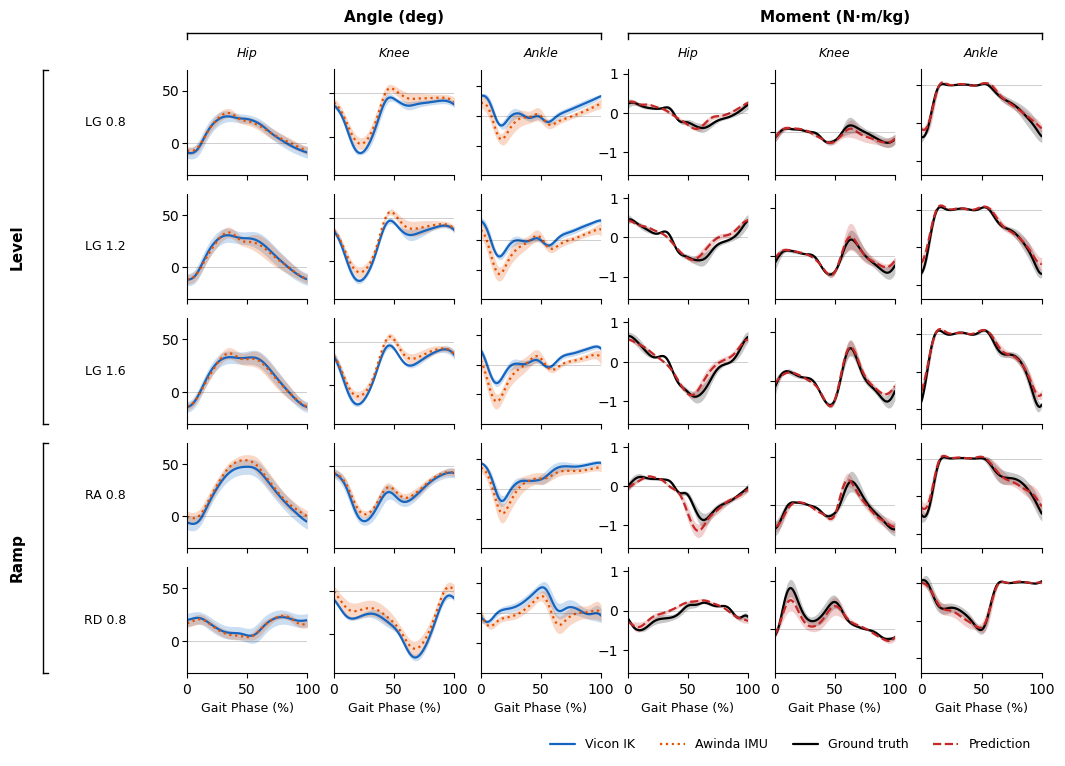

,joint,condition,label,n_subjects,rmse_mean,rmse_sd,r2_mean,r2_sd
0,hip,LG_0p8mps,LG 0.8,7,0.0967,0.0234,0.7698,0.1277
1,hip,LG_1p2mps,LG 1.2,8,0.1340,0.0256,0.8287,0.0780
2,hip,LG_1p6mps,LG 1.6,8,0.1433,0.0181,0.9053,0.0332
3,hip,RA_0p8mps,RA 0.8,8,0.1980,0.0693,0.6218,0.2604
4,hip,RD_0p8mps,RD 0.8,8,0.1197,0.0269,0.6896,0.1295
5,knee,LG_0p8mps,LG 0.8,7,0.0973,0.0444,0.0384,1.3302
6,knee,LG_1p2mps,LG 1.2,8,0.0913,0.0500,0.8056,0.1555
7,knee,LG_1p6mps,LG 1.6,8,0.0931,0.0411,0.9003,0.0722
8,knee,RA_0p8mps,RA 0.8,8,0.1235,0.0538,0.7432,0.1767
9,knee,RD_0p8mps,RD 0.8,8,0.1242,0.0730,0.7666,0.3146


Saved → /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_paper_condition_metrics_heatmap.png (+ .pdf)


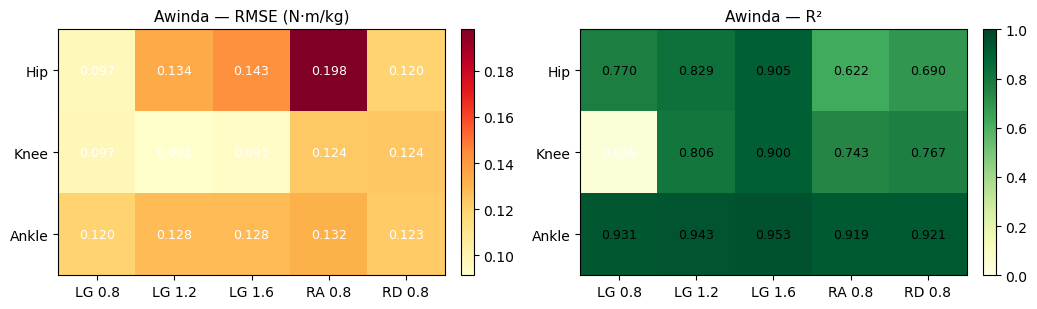

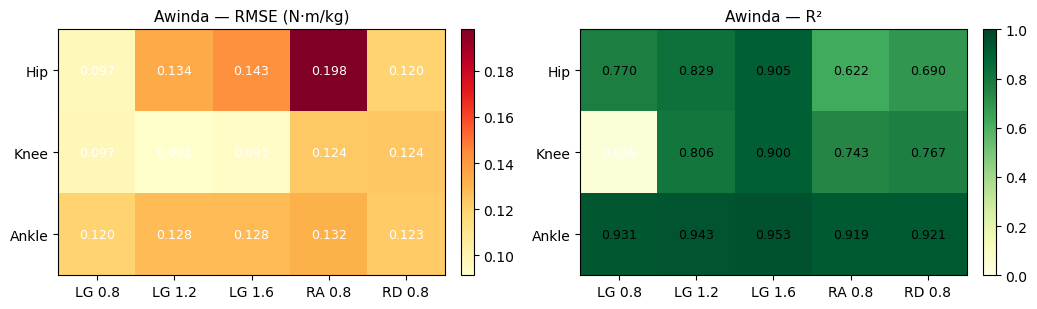

In [15]:
def _rmse_r2_1d(y_true: np.ndarray, y_pred: np.ndarray) -> Tuple[float, float]:
    yt = np.asarray(y_true, dtype=np.float64).reshape(-1)
    yp = np.asarray(y_pred, dtype=np.float64).reshape(-1)
    m = np.isfinite(yt) & np.isfinite(yp)
    if m.sum() < 3:
        return float('nan'), float('nan')
    e = yp[m] - yt[m]
    rmse = float(np.sqrt(np.mean(e ** 2)))
    ss_res = float(np.sum(e ** 2))
    ss_tot = float(np.sum((yt[m] - np.mean(yt[m])) ** 2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 1e-12 else float('nan')
    return rmse, r2



def _paper_style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)




def _plot_mean_sd(ax, pct, stack, color, ls='-', lw=1.6, label=None, band_alpha=0.22):
    stack = np.asarray(stack, dtype=np.float64)
    if stack.size == 0:
        return
    mu = np.mean(stack, axis=0)
    sd = np.std(stack, axis=0, ddof=1) if stack.shape[0] > 1 else np.zeros_like(mu)
    ax.fill_between(pct, mu - sd, mu + sd, color=color, alpha=band_alpha, linewidth=0, zorder=1)
    ax.plot(pct, mu, color=color, lw=lw, ls=ls, solid_capstyle='round', label=label, zorder=2)


def _ylim_from_stacks(stacks, pad=0.10):
    vals = np.concatenate([np.asarray(s).ravel() for s in stacks if np.size(s)])
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return (-1.0, 1.0)
    lo, hi = float(np.min(vals)), float(np.max(vals))
    span = max(hi - lo, 1e-3)
    return lo - pad * span, hi + pad * span


def _draw_col_brackets(fig, axs, groups, sublabels=None):
    """groups: [(label, c0, c1), ...]. sublabels: [(text, col), ...] italic under brackets."""
    top_axs = axs[0, :]
    for label, c0, c1 in groups:
        p0, p1 = top_axs[c0].get_position(), top_axs[c1].get_position()
        x0, x1 = p0.x0, p1.x1
        y = p0.y1 + 0.045
        fig.add_artist(plt.Line2D([x0, x1], [y, y], transform=fig.transFigure,
                                  color='k', lw=1.0, clip_on=False))
        fig.add_artist(plt.Line2D([x0, x0], [y - 0.007, y], transform=fig.transFigure,
                                  color='k', lw=1.0, clip_on=False))
        fig.add_artist(plt.Line2D([x1, x1], [y - 0.007, y], transform=fig.transFigure,
                                  color='k', lw=1.0, clip_on=False))
        fig.text((x0 + x1) / 2, y + 0.010, label, ha='center', va='bottom',
                 fontsize=11, fontweight='bold', transform=fig.transFigure)
    if sublabels:
        for text, col in sublabels:
            p = top_axs[col].get_position()
            fig.text(
                0.5 * (p.x0 + p.x1), p.y1 + 0.012, text,
                ha='center', va='bottom', fontsize=9, fontstyle='italic',
                transform=fig.transFigure,
            )


def _draw_row_brackets(fig, axs, groups, x_offset=0.13):
    """Vertical group bracket + label well left of condition labels."""
    left = axs[:, 0]
    for label, r0, r1 in groups:
        p0, p1 = left[r0].get_position(), left[r1].get_position()
        x = p0.x0 - x_offset
        y0, y1 = p1.y0, p0.y1
        fig.add_artist(plt.Line2D([x, x], [y0, y1], transform=fig.transFigure,
                                  color='k', lw=1.0, clip_on=False))
        fig.add_artist(plt.Line2D([x, x + 0.005], [y0, y0], transform=fig.transFigure,
                                  color='k', lw=1.0, clip_on=False))
        fig.add_artist(plt.Line2D([x, x + 0.005], [y1, y1], transform=fig.transFigure,
                                  color='k', lw=1.0, clip_on=False))
        fig.text(x - 0.016, (y0 + y1) / 2, label, ha='right', va='center', rotation=90,
                 fontsize=11, fontweight='bold', transform=fig.transFigure)


def _draw_row_condition_labels(fig, axs, labels, x_offset=0.055):
    """Condition labels between group brackets and the axes."""
    left = axs[:, 0]
    for i, lab in enumerate(labels):
        p = left[i].get_position()
        fig.text(
            p.x0 - x_offset, 0.5 * (p.y0 + p.y1), lab,
            ha='right', va='center', fontsize=9, transform=fig.transFigure,
        )


def plot_awinda_paper_waveforms(
    gait_by_condition: Dict[str, List[Dict]],
    conditions: List[str] = None,
    save_path: Optional[Path] = None,
):
    """
    Reference-style paper figure:
      rows = conditions, cols = Angle(Hip,Knee,Ankle) | Moment(Hip,Knee,Ankle)
    """
    conditions = list(conditions or PAPER_CONDITIONS)
    n_row = len(conditions)
    n_joint = len(JOINT_ORDER)
    n_col = 2 * n_joint
    pct = np.linspace(0.0, 100.0, N_GAIT_PTS)
    joint_titles = [j.capitalize() for j in JOINT_ORDER]

    # stacks[kind][joint][cond] -> (n_subj, n_pts)
    kinds = ('angle', 'enc', 'gt', 'pred')
    stacks = {k: {j: {} for j in JOINT_ORDER} for k in kinds}

    for cond in conditions:
        trials = gait_by_condition.get(cond, [])
        for j_idx, joint in enumerate(JOINT_ORDER):
            ang, enc, gt, pr = [], [], [], []
            for t in trials:
                a = np.asarray(t['angle_subject_means'][j_idx], dtype=np.float64)
                e = np.asarray(t['encoder_subject_means'][j_idx], dtype=np.float64)
                g = np.asarray(t['gt_subject_means'][j_idx], dtype=np.float64)
                p = np.asarray(t['model_subject_means'][j_idx], dtype=np.float64)
                if np.all(np.isfinite(a)):
                    ang.append(a)
                if np.all(np.isfinite(e)):
                    enc.append(e)
                gt.append(g)
                pr.append(p)
            stacks['angle'][joint][cond] = np.vstack(ang) if ang else np.empty((0, N_GAIT_PTS))
            stacks['enc'][joint][cond] = np.vstack(enc) if enc else np.empty((0, N_GAIT_PTS))
            stacks['gt'][joint][cond] = np.vstack(gt) if gt else np.empty((0, N_GAIT_PTS))
            stacks['pred'][joint][cond] = np.vstack(pr) if pr else np.empty((0, N_GAIT_PTS))

    ylim_ang = [
        _ylim_from_stacks([stacks['angle'][j][c] for c in conditions] + [stacks['enc'][j][c] for c in conditions])
        for j in JOINT_ORDER
    ]
    ylim_mom = [
        _ylim_from_stacks([stacks['gt'][j][c] for c in conditions] + [stacks['pred'][j][c] for c in conditions])
        for j in JOINT_ORDER
    ]

    fig, axs = plt.subplots(
        n_row, n_col,
        figsize=(1.55 * n_col + 1.8, 1.35 * n_row + 1.4),
        sharex=True, sharey=False,
        gridspec_kw={'wspace': 0.22, 'hspace': 0.18},
    )
    if n_row == 1:
        axs = np.asarray(axs).reshape(1, n_col)

    legend_handles = None
    for i, cond in enumerate(conditions):
        for j_idx, joint in enumerate(JOINT_ORDER):
            # angle column
            c_ang = j_idx
            ax = axs[i, c_ang]
            _paper_style_ax(ax)
            show_leg = (i == 0 and j_idx == 0)
            _plot_mean_sd(ax, pct, stacks['angle'][joint][cond], ANGLE_COLOR,
                          label='Vicon IK' if show_leg else None)
            _plot_mean_sd(ax, pct, stacks['enc'][joint][cond], ENCODER_COLOR, ls=':',
                          label='Awinda IMU' if show_leg else None)
            ax.set_ylim(*ylim_ang[j_idx])
            ax.set_xlim(0, 100)
            ax.axhline(0, color='k', lw=0.45, alpha=0.30)
            if i == n_row - 1:
                ax.set_xlabel('Gait Phase (%)', fontsize=9)
            else:
                ax.tick_params(labelbottom=False)
            if show_leg:
                legend_handles = ax.get_legend_handles_labels()

            # moment column
            c_mom = n_joint + j_idx
            ax = axs[i, c_mom]
            _paper_style_ax(ax)
            show_leg_m = (i == 0 and j_idx == 0)
            _plot_mean_sd(ax, pct, stacks['gt'][joint][cond], GT_COLOR,
                          label='Ground truth' if show_leg_m else None)
            _plot_mean_sd(ax, pct, stacks['pred'][joint][cond], PRED_COLOR, ls='--',
                          label='Prediction' if show_leg_m else None)
            ax.set_ylim(*ylim_mom[j_idx])
            ax.set_xlim(0, 100)
            ax.axhline(0, color='k', lw=0.45, alpha=0.30)
            if i == n_row - 1:
                ax.set_xlabel('Gait Phase (%)', fontsize=9)
            else:
                ax.tick_params(labelbottom=False)
            if show_leg_m:
                h2, l2 = ax.get_legend_handles_labels()
                if legend_handles:
                    legend_handles = (legend_handles[0] + h2, legend_handles[1] + l2)
                else:
                    legend_handles = (h2, l2)

    # share y within each column manually already via ylims; tick labels only leftmost of each group
    for i in range(n_row):
        for c in range(n_col):
            if c not in (0, n_joint):
                axs[i, c].tick_params(labelleft=False)

    for _ax in axs[:, 0]:
        _ax.tick_params(axis='y', pad=2)

    fig.subplots_adjust(left=0.22, right=0.99, top=0.86, bottom=0.12)
    _draw_col_brackets(
        fig, axs,
        [('Angle (deg)', 0, n_joint - 1), ('Moment (N·m/kg)', n_joint, n_col - 1)],
        sublabels=(
            [(joint_titles[j], j) for j in range(n_joint)]
            + [(joint_titles[j], n_joint + j) for j in range(n_joint)]
        ),
    )
    level_idx = [i for i, c in enumerate(conditions) if c.startswith('LG_')]
    ramp_idx = [i for i, c in enumerate(conditions) if c.startswith('RA_') or c.startswith('RD_')]
    row_groups = []
    if level_idx:
        row_groups.append(('Level', level_idx[0], level_idx[-1]))
    if ramp_idx:
        row_groups.append(('Ramp', ramp_idx[0], ramp_idx[-1]))
    if row_groups:
        _draw_row_brackets(fig, axs, row_groups)
    _draw_row_condition_labels(
        fig, axs,
        [PAPER_CONDITION_LABELS.get(c, c) for c in conditions],
    )

    if legend_handles and legend_handles[0]:
        fig.legend(
            legend_handles[0], legend_handles[1],
            loc='lower right', ncol=min(5, len(legend_handles[0])),
            frameon=False, fontsize=9, bbox_to_anchor=(0.99, 0.01),
        )

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        fig.savefig(save_path.with_suffix('.pdf'), bbox_inches='tight')
        print(f'Saved → {save_path} (+ .pdf)')
    plt.show()
    return fig


def compute_awinda_condition_metrics(
    gait_by_condition: Dict[str, List[Dict]],
    conditions: List[str] = None,
) -> pd.DataFrame:
    """Per joint×condition: mean±SD of per-subject RMSE/R² on subject-mean cycles."""
    conditions = list(conditions or PAPER_CONDITIONS)
    rows = []
    for joint in JOINT_ORDER:
        j_idx = JOINT_ORDER.index(joint)
        for cond in conditions:
            rmses, r2s = [], []
            for t in gait_by_condition.get(cond, []):
                rmse, r2 = _rmse_r2_1d(
                    t['gt_subject_means'][j_idx],
                    t['model_subject_means'][j_idx],
                )
                if np.isfinite(rmse):
                    rmses.append(rmse)
                if np.isfinite(r2):
                    r2s.append(r2)
            rows.append({
                'joint': joint,
                'condition': cond,
                'label': PAPER_CONDITION_LABELS.get(cond, cond),
                'n_subjects': len(gait_by_condition.get(cond, [])),
                'rmse_mean': float(np.mean(rmses)) if rmses else np.nan,
                'rmse_sd': float(np.std(rmses, ddof=1)) if len(rmses) > 1 else 0.0,
                'r2_mean': float(np.mean(r2s)) if r2s else np.nan,
                'r2_sd': float(np.std(r2s, ddof=1)) if len(r2s) > 1 else 0.0,
            })
    return pd.DataFrame(rows)


def plot_awinda_metric_heatmaps(metrics_df: pd.DataFrame, save_path: Optional[Path] = None):
    """3×5 heatmaps for RMSE and R² (rows=joints, cols=conditions)."""
    conditions = list(PAPER_CONDITIONS)
    col_labels = [PAPER_CONDITION_LABELS.get(c, c) for c in conditions]
    rmse = np.full((len(JOINT_ORDER), len(conditions)), np.nan)
    r2 = np.full_like(rmse, np.nan)
    for i, joint in enumerate(JOINT_ORDER):
        for j, cond in enumerate(conditions):
            row = metrics_df[(metrics_df['joint'] == joint) & (metrics_df['condition'] == cond)]
            if len(row):
                rmse[i, j] = float(row['rmse_mean'].iloc[0])
                r2[i, j] = float(row['r2_mean'].iloc[0])

    fig, axs = plt.subplots(1, 2, figsize=(10.5, 3.2))
    for ax, data, title, cmap, vmin, vmax in (
        (axs[0], rmse, 'Awinda — RMSE (N·m/kg)', 'YlOrRd', None, None),
        (axs[1], r2, 'Awinda — R²', 'YlGn', 0.0, 1.0),
    ):
        im = ax.imshow(data, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_yticks(range(len(JOINT_ORDER)))
        ax.set_yticklabels([j.capitalize() for j in JOINT_ORDER])
        ax.set_xticks(range(len(col_labels)))
        ax.set_xticklabels(col_labels, rotation=0)
        ax.set_title(title, fontsize=11)
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                v = data[i, j]
                if not np.isfinite(v):
                    continue
                if title.startswith('Awinda — R'):
                    color = 'white' if v < 0.55 else 'black'
                else:
                    color = 'black' if v < np.nanmedian(data) else 'white'
                ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=9, color=color)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        fig.savefig(save_path.with_suffix('.pdf'), bbox_inches='tight')
        print(f'Saved → {save_path} (+ .pdf)')
    plt.show()
    return fig


# --- build / show ---
_missing_angle = [
    t for trials in GAIT_BY_CONDITION.values() for t in trials
    if 'angle_subject_means' not in t
    or any(not np.all(np.isfinite(a)) for a in t['angle_subject_means'])
]
if _missing_angle:
    print(
        f'NOTE: {len(_missing_angle)} trial(s) lack angle_subject_means — '
        're-run the HS-helpers + §2 segment cells, then re-run this cell.'
    )

missing = [c for c in PAPER_CONDITIONS if c not in GAIT_BY_CONDITION or not GAIT_BY_CONDITION[c]]
if missing:
    print('Warning: missing conditions for paper figure:', missing)

FIG_DIR.mkdir(parents=True, exist_ok=True)
plot_awinda_paper_waveforms(
    GAIT_BY_CONDITION,
    conditions=PAPER_CONDITIONS,
    save_path=FIG_DIR / 'awinda_paper_angle_moment_by_condition.png',
)

PAPER_METRICS_DF = compute_awinda_condition_metrics(GAIT_BY_CONDITION, PAPER_CONDITIONS)
display(PAPER_METRICS_DF.round(4))
PAPER_METRICS_DF.to_csv(CACHE_DIR / 'awinda_paper_condition_metrics.csv', index=False)

plot_awinda_metric_heatmaps(
    PAPER_METRICS_DF,
    save_path=FIG_DIR / 'awinda_paper_condition_metrics_heatmap.png',
)


## 4. Plot GT gait-cycle moment profiles (per joint)



=== Plotting GT for hip_flexion_r ===
Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_hip_flexion_r_LG_0p8mps.png


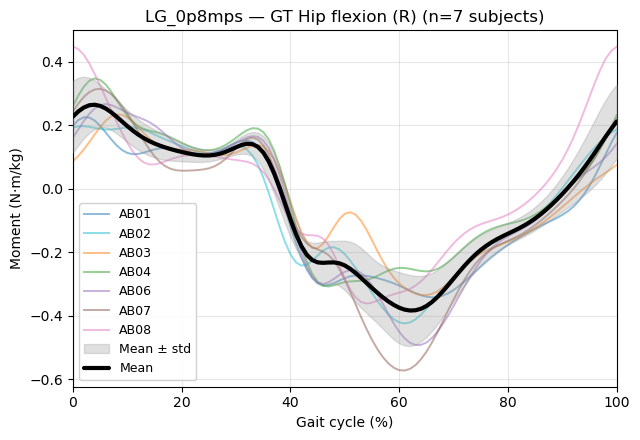

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_hip_flexion_r_LG_1p2mps.png


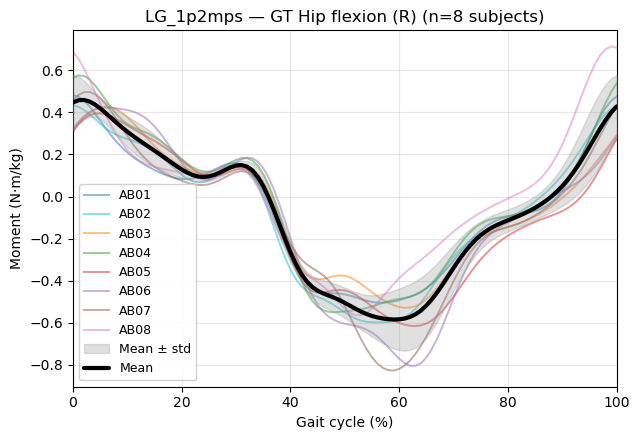

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_hip_flexion_r_LG_1p6mps.png


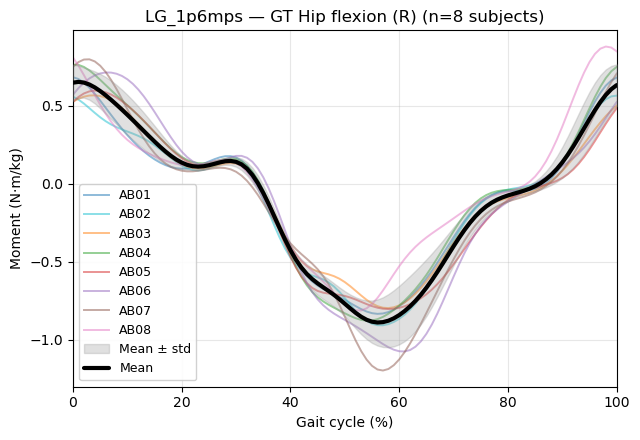

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_hip_flexion_r_RA_0p8mps.png


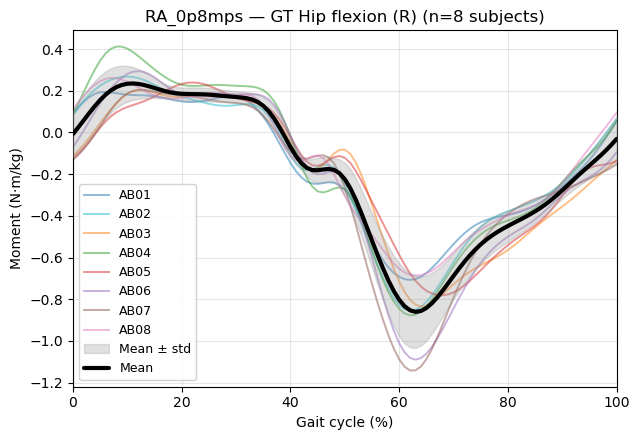

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_hip_flexion_r_RD_0p8mps.png


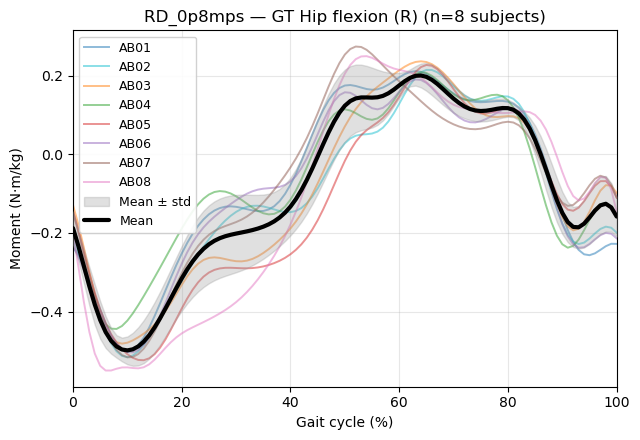


=== Plotting GT for knee_angle_r ===
Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_knee_angle_r_LG_0p8mps.png


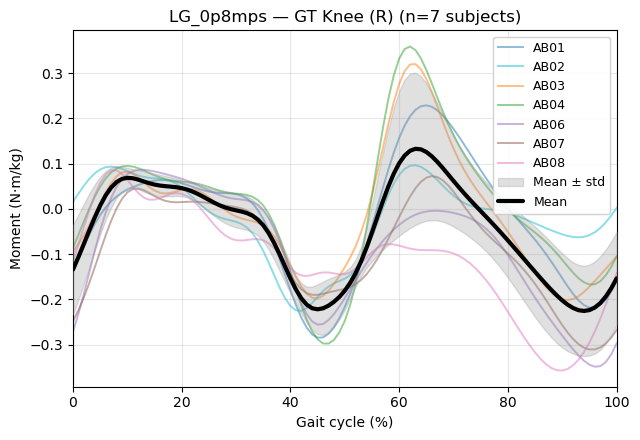

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_knee_angle_r_LG_1p2mps.png


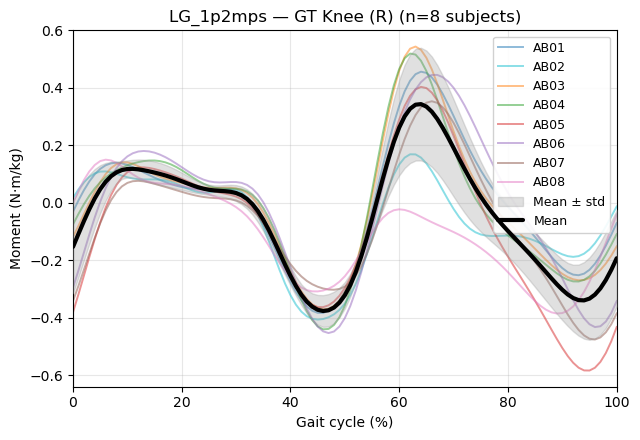

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_knee_angle_r_LG_1p6mps.png


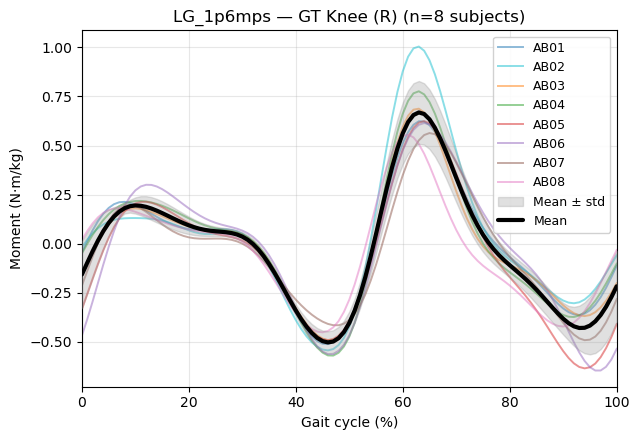

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_knee_angle_r_RA_0p8mps.png


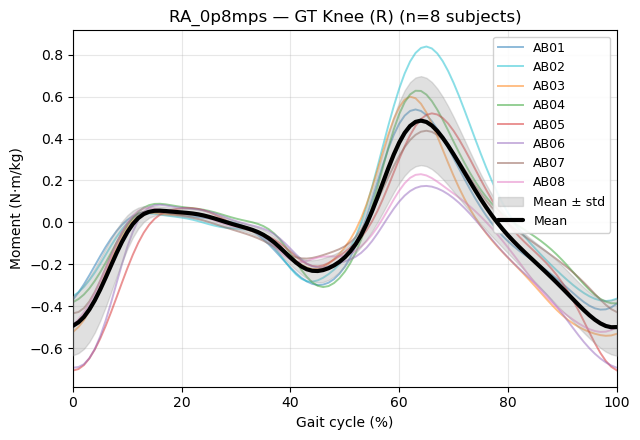

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_knee_angle_r_RD_0p8mps.png


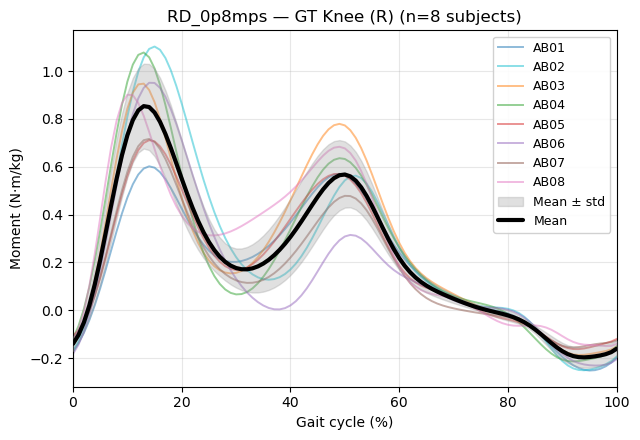


=== Plotting GT for ankle_angle_r ===
Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_ankle_angle_r_LG_0p8mps.png


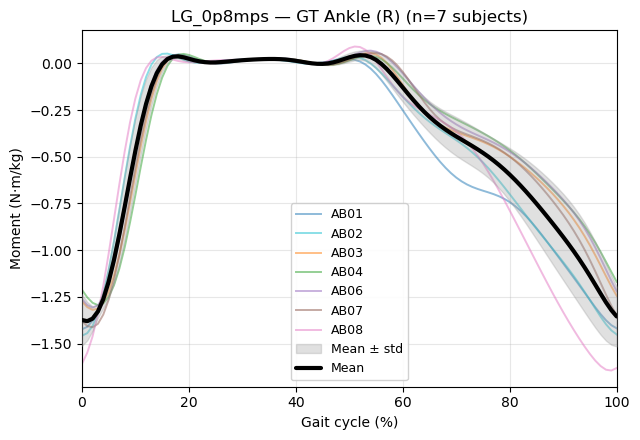

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_ankle_angle_r_LG_1p2mps.png


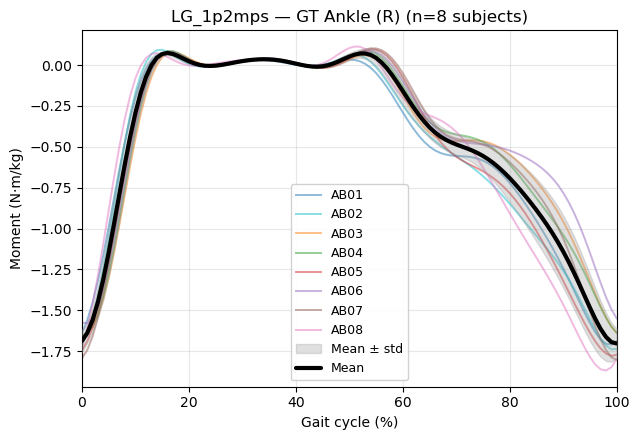

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_ankle_angle_r_LG_1p6mps.png


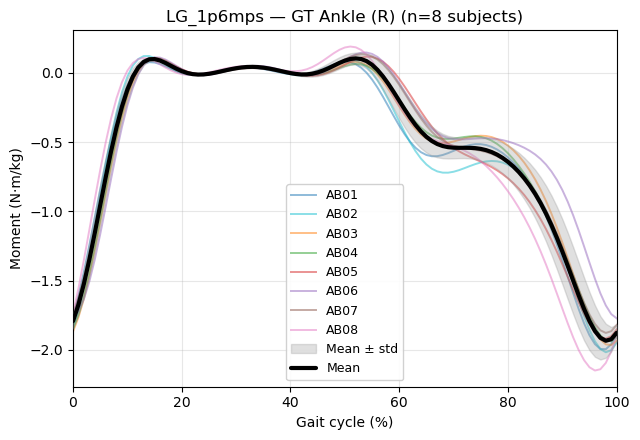

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_ankle_angle_r_RA_0p8mps.png


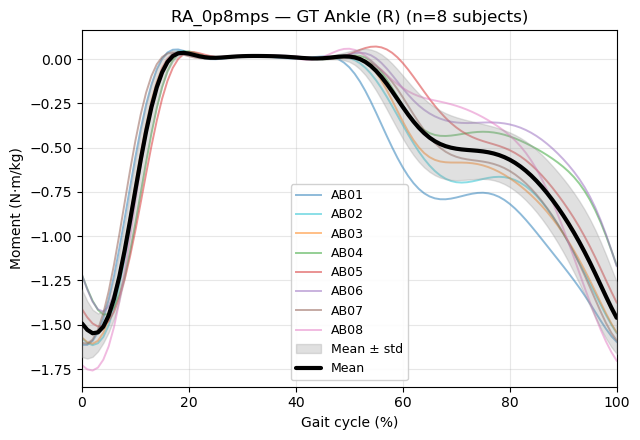

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_gt_ankle_angle_r_RD_0p8mps.png


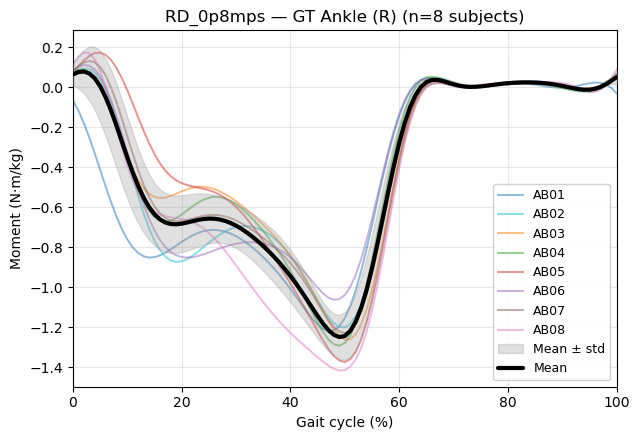

In [16]:
def plot_condition_joint_gt(
    condition: str,
    joint_idx: int,
    joint_name: str,
    trials: List[Dict],
    ax=None,
    save_path: Optional[Path] = None,
):
    if not trials:
        raise ValueError(f'No trials for condition {condition}')

    pct = trials[0]['pct']
    subject_means = [np.asarray(t['gt_subject_means'][joint_idx], dtype=np.float64) for t in trials]
    subjects = [t['subject'] for t in trials]
    grand_mean = np.mean(subject_means, axis=0)
    grand_std = np.std(subject_means, axis=0, ddof=1) if len(subject_means) > 1 else np.zeros_like(grand_mean)

    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(6.5, 4.5))
    else:
        fig = ax.figure

    for subj, subj_mean in zip(subjects, subject_means):
        color = SUBJECT_COLORS.get(subj, '#999999')
        subj_id = subj.split('_')[0]
        ax.plot(
            pct,
            subj_mean,
            color=color,
            alpha=SUBJECT_LINE_ALPHA,
            lw=1.4,
            label=subj_id,
        )

    ax.fill_between(
        pct,
        grand_mean - grand_std,
        grand_mean + grand_std,
        color=GRAND_MEAN_STD_COLOR,
        alpha=GRAND_MEAN_STD_ALPHA,
        label='Mean ± std',
        zorder=5,
    )
    ax.plot(
        pct,
        grand_mean,
        color=GRAND_MEAN_COLOR,
        lw=3.0,
        solid_capstyle='round',
        label='Mean',
        zorder=10,
    )
    ax.axvline(0.0, color='0.75', lw=0.8, zorder=0)
    ax.set_xlim(0, 100)
    ax.set_xlabel('Gait cycle (%)')
    ax.set_ylabel('Moment (N·m/kg)')
    ax.set_title(f'{condition} — GT {joint_name} (n={len(trials)} subjects)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', frameon=True, framealpha=0.9, fontsize=9)

    if created_fig:
        fig.tight_layout()
        if save_path is not None:
            save_path.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f'Saved {save_path}')
        plt.show()

    return fig, ax


conditions = sorted(GAIT_BY_CONDITION.keys())
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Plot each joint separately
for j_idx, (joint_name, joint_label) in enumerate(zip(RIGHT_CHANNELS, RIGHT_LABELS)):
    print(f'\n=== Plotting GT for {joint_name} ===')
    for condition in conditions:
        plot_condition_joint_gt(
            condition,
            j_idx,
            joint_label,
            GAIT_BY_CONDITION[condition],
            save_path=FIG_DIR / f'awinda_gt_{joint_name}_{condition}.png',
        )

## 5. Plot model estimate gait-cycle moment profiles (per joint)



=== Plotting Model for hip_flexion_r ===
Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_hip_flexion_r_LG_0p8mps.png


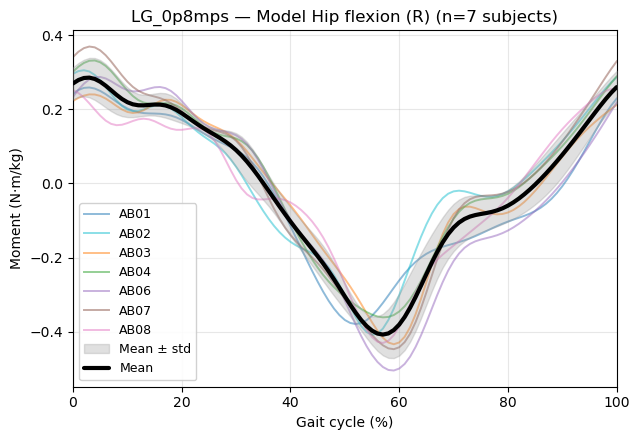

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_hip_flexion_r_LG_1p2mps.png


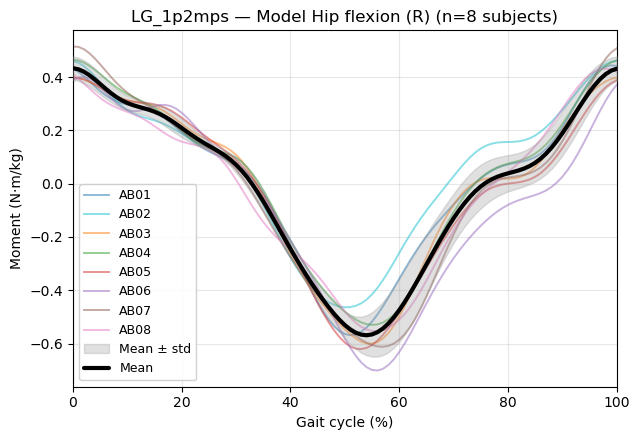

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_hip_flexion_r_LG_1p6mps.png


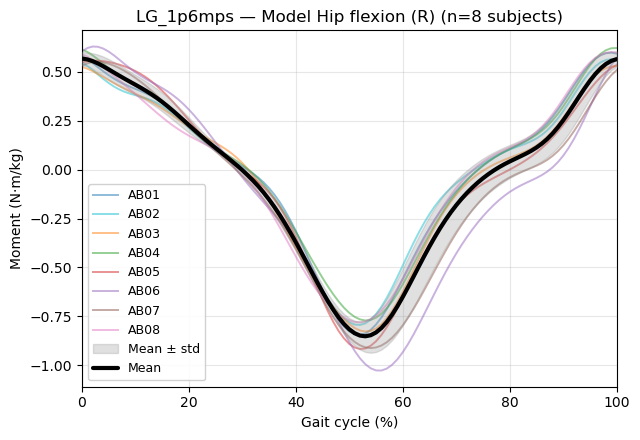

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_hip_flexion_r_RA_0p8mps.png


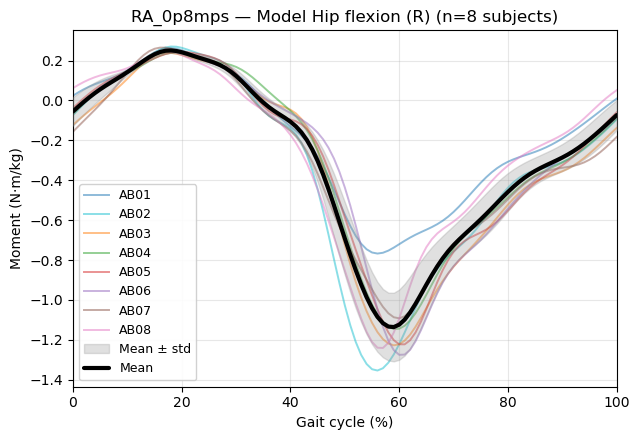

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_hip_flexion_r_RD_0p8mps.png


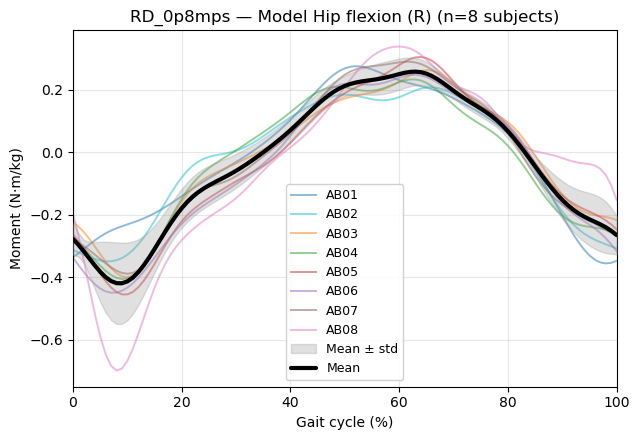


=== Plotting Model for knee_angle_r ===
Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_knee_angle_r_LG_0p8mps.png


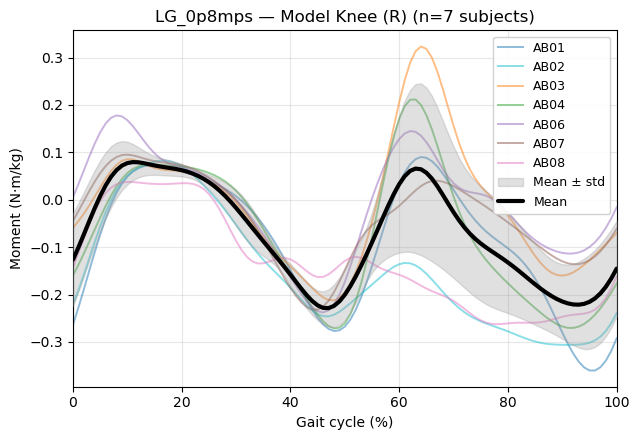

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_knee_angle_r_LG_1p2mps.png


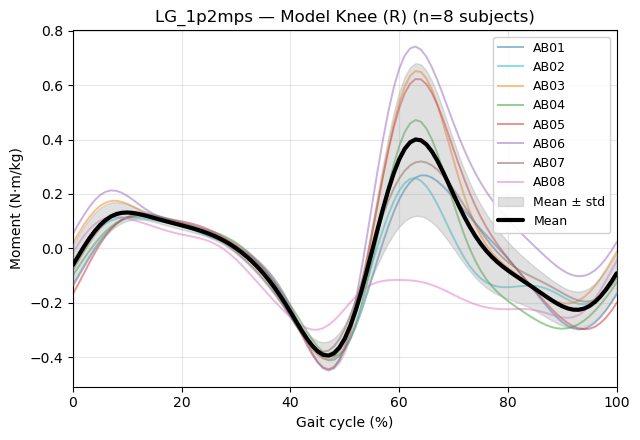

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_knee_angle_r_LG_1p6mps.png


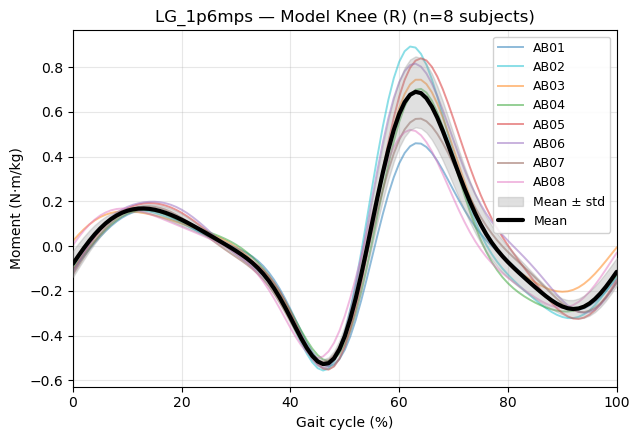

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_knee_angle_r_RA_0p8mps.png


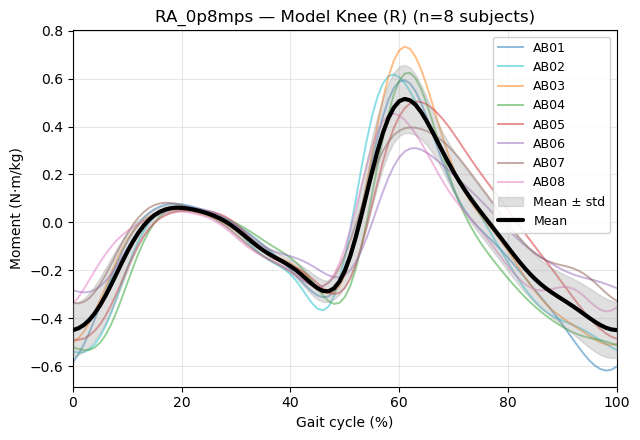

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_knee_angle_r_RD_0p8mps.png


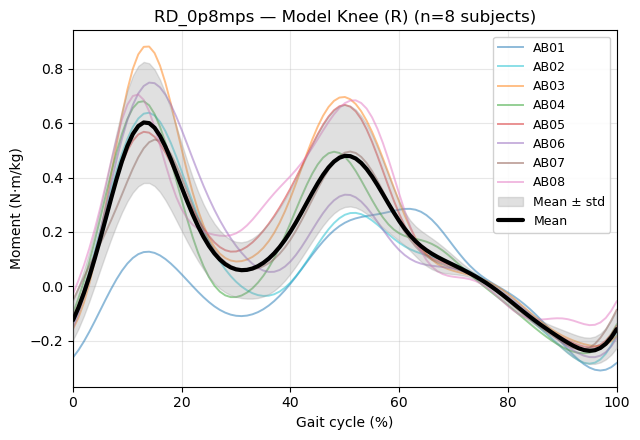


=== Plotting Model for ankle_angle_r ===
Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_ankle_angle_r_LG_0p8mps.png


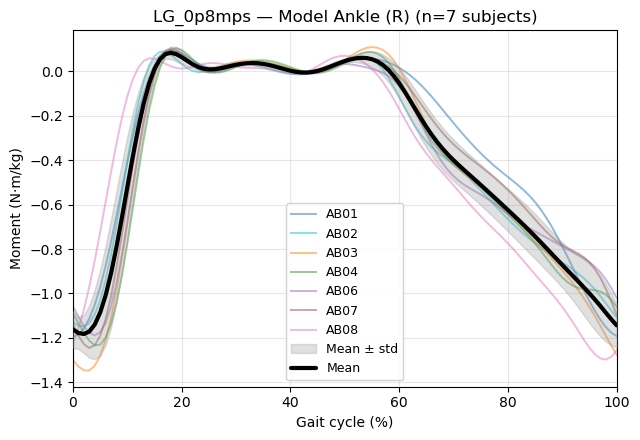

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_ankle_angle_r_LG_1p2mps.png


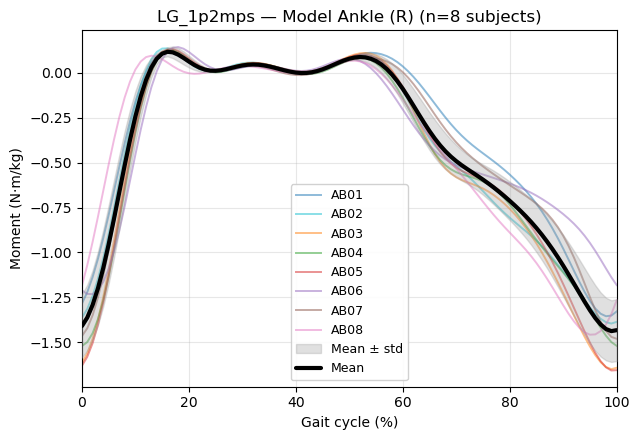

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_ankle_angle_r_LG_1p6mps.png


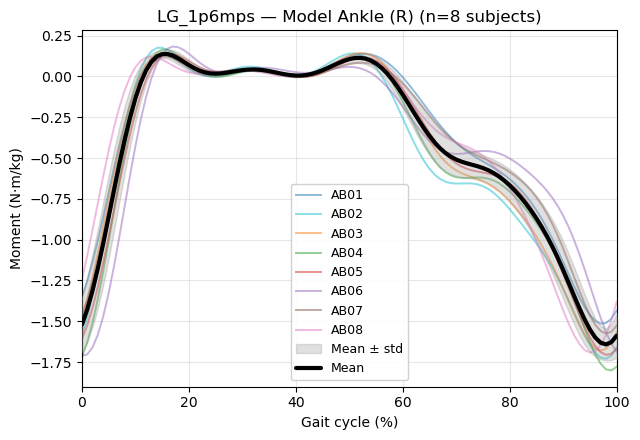

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_ankle_angle_r_RA_0p8mps.png


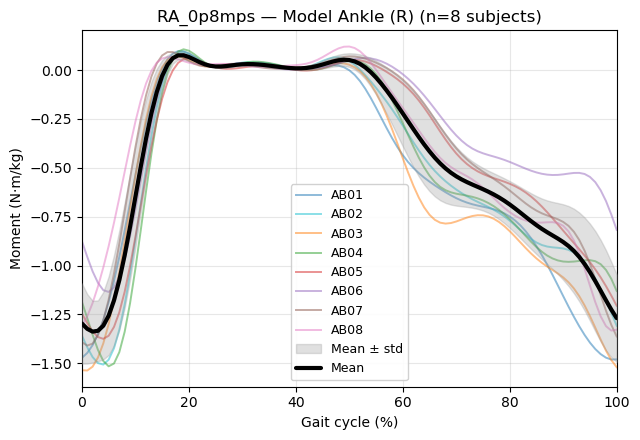

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_model_ankle_angle_r_RD_0p8mps.png


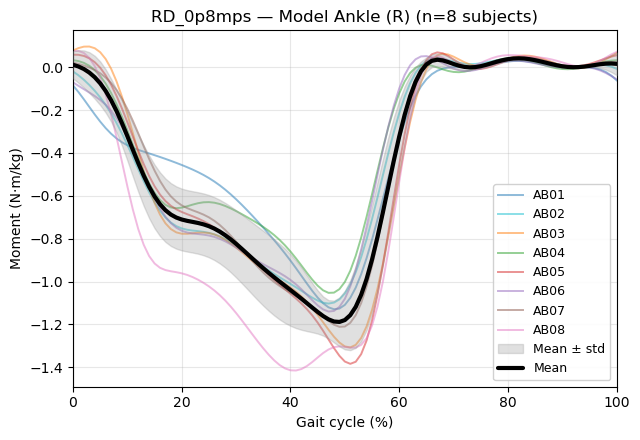

In [17]:
def plot_condition_joint_model(
    condition: str,
    joint_idx: int,
    joint_name: str,
    trials: List[Dict],
    ax=None,
    save_path: Optional[Path] = None,
):
    if not trials:
        raise ValueError(f'No trials for condition {condition}')

    pct = trials[0]['pct']
    subject_means = [np.asarray(t['model_subject_means'][joint_idx], dtype=np.float64) for t in trials]
    subjects = [t['subject'] for t in trials]
    grand_mean = np.mean(subject_means, axis=0)
    grand_std = np.std(subject_means, axis=0, ddof=1) if len(subject_means) > 1 else np.zeros_like(grand_mean)

    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(6.5, 4.5))
    else:
        fig = ax.figure

    for subj, subj_mean in zip(subjects, subject_means):
        color = SUBJECT_COLORS.get(subj, '#999999')
        subj_id = subj.split('_')[0]
        ax.plot(
            pct,
            subj_mean,
            color=color,
            alpha=SUBJECT_LINE_ALPHA,
            lw=1.4,
            label=subj_id,
        )

    ax.fill_between(
        pct,
        grand_mean - grand_std,
        grand_mean + grand_std,
        color=GRAND_MEAN_STD_COLOR,
        alpha=GRAND_MEAN_STD_ALPHA,
        label='Mean ± std',
        zorder=5,
    )
    ax.plot(
        pct,
        grand_mean,
        color=GRAND_MEAN_COLOR,
        lw=3.0,
        solid_capstyle='round',
        label='Mean',
        zorder=10,
    )
    ax.axvline(0.0, color='0.75', lw=0.8, zorder=0)
    ax.set_xlim(0, 100)
    ax.set_xlabel('Gait cycle (%)')
    ax.set_ylabel('Moment (N·m/kg)')
    ax.set_title(f'{condition} — Model {joint_name} (n={len(trials)} subjects)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', frameon=True, framealpha=0.9, fontsize=9)

    if created_fig:
        fig.tight_layout()
        if save_path is not None:
            save_path.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f'Saved {save_path}')
        plt.show()

    return fig, ax


# Plot each joint separately
for j_idx, (joint_name, joint_label) in enumerate(zip(RIGHT_CHANNELS, RIGHT_LABELS)):
    print(f'\n=== Plotting Model for {joint_name} ===')
    for condition in conditions:
        plot_condition_joint_model(
            condition,
            j_idx,
            joint_label,
            GAIT_BY_CONDITION[condition],
            save_path=FIG_DIR / f'awinda_model_{joint_name}_{condition}.png',
        )

## 6. GT vs Model comparison (grand means only, per joint)



=== Plotting GT vs Model for hip_flexion_r ===
Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_hip_flexion_r_LG_0p8mps.png


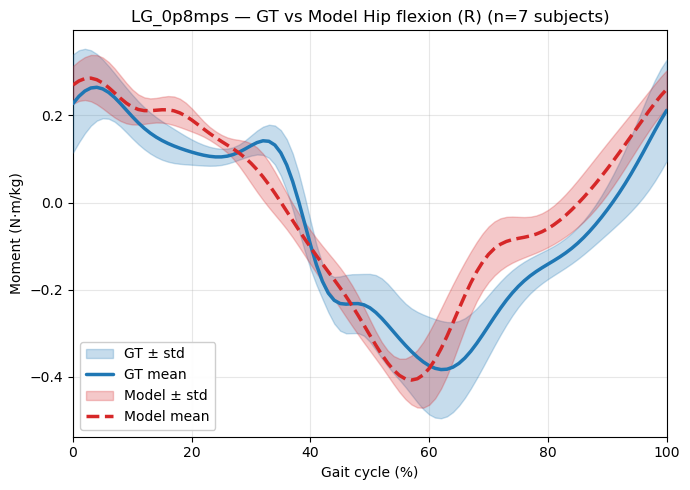

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_hip_flexion_r_LG_1p2mps.png


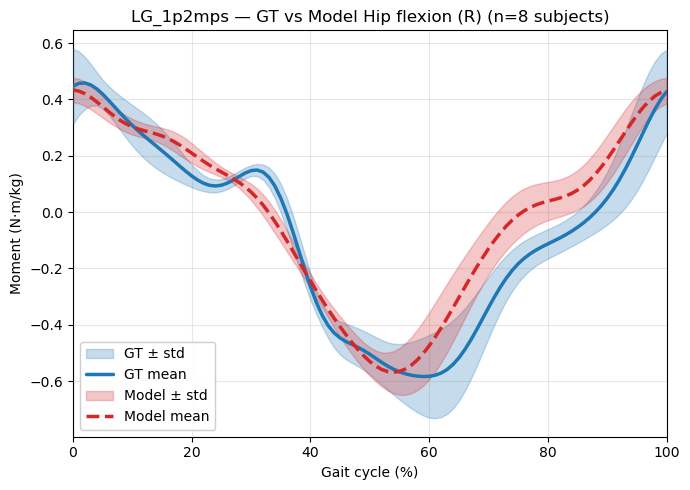

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_hip_flexion_r_LG_1p6mps.png


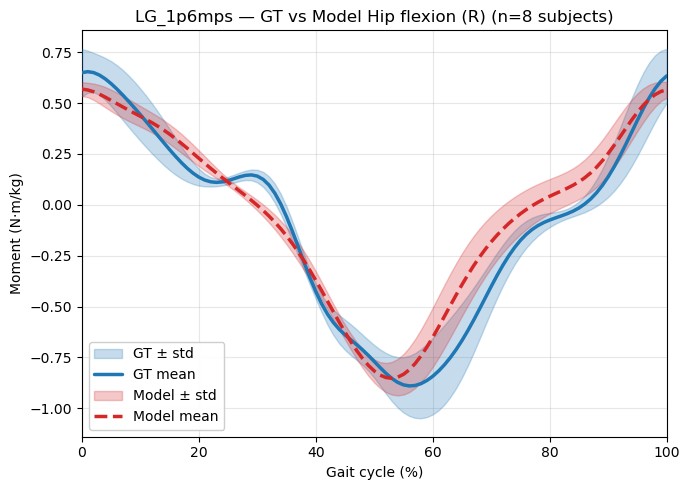

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_hip_flexion_r_RA_0p8mps.png


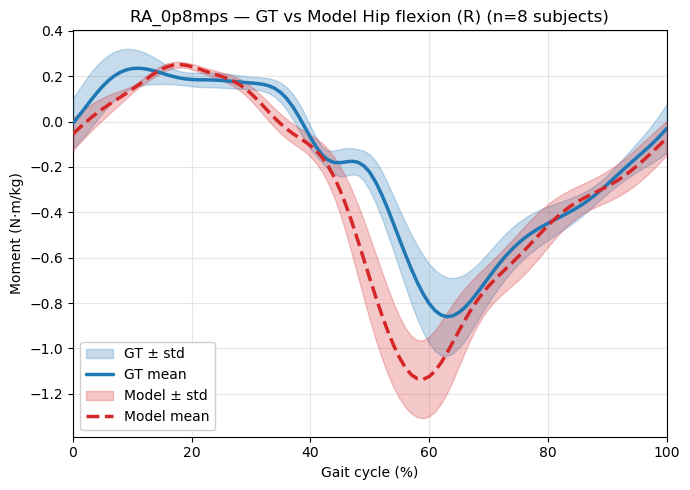

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_hip_flexion_r_RD_0p8mps.png


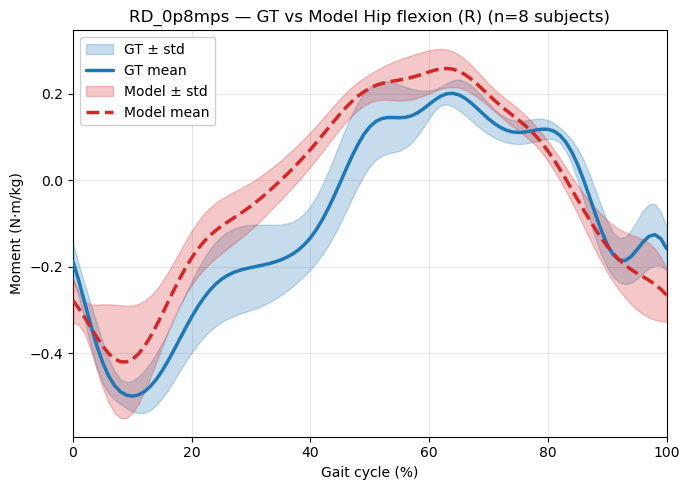


=== Plotting GT vs Model for knee_angle_r ===
Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_knee_angle_r_LG_0p8mps.png


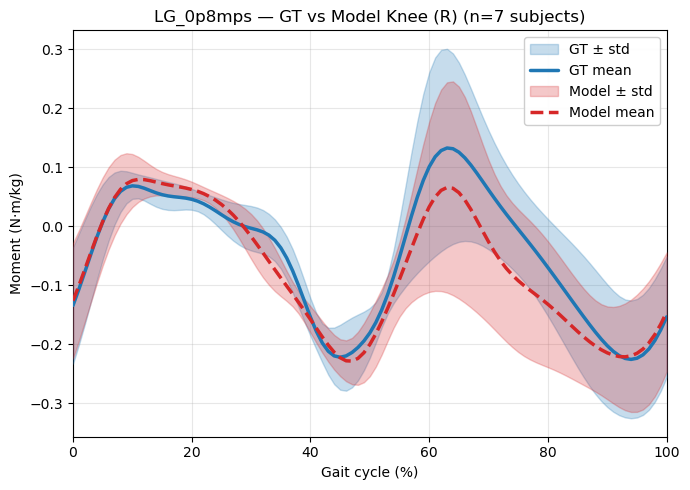

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_knee_angle_r_LG_1p2mps.png


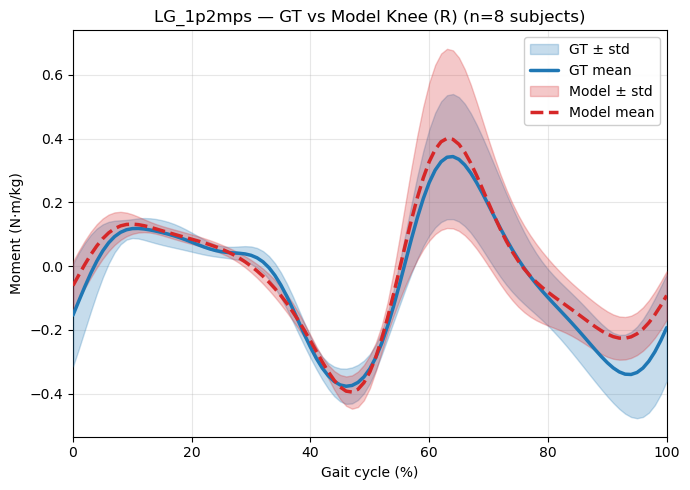

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_knee_angle_r_LG_1p6mps.png


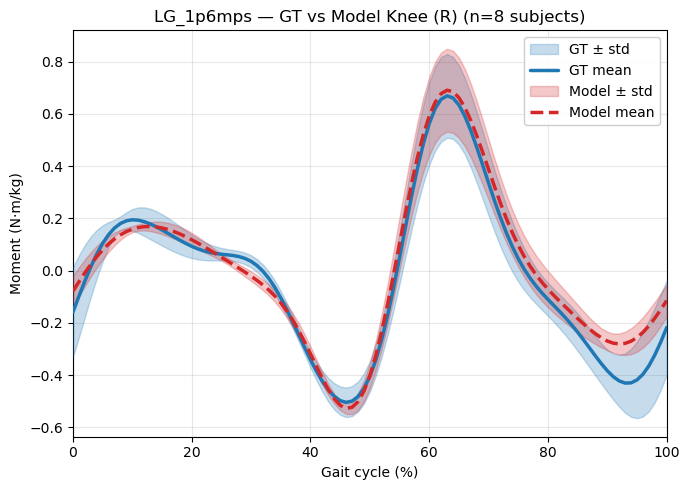

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_knee_angle_r_RA_0p8mps.png


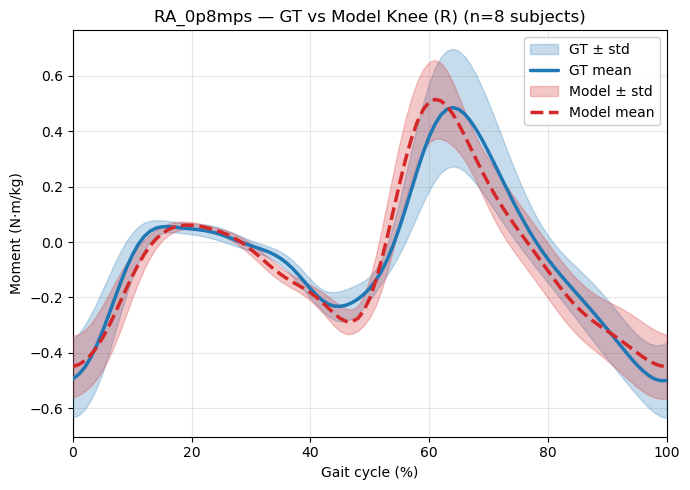

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_knee_angle_r_RD_0p8mps.png


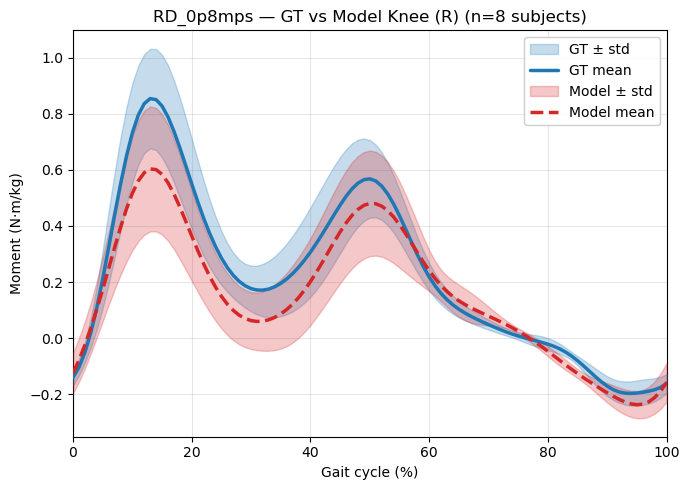


=== Plotting GT vs Model for ankle_angle_r ===
Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_ankle_angle_r_LG_0p8mps.png


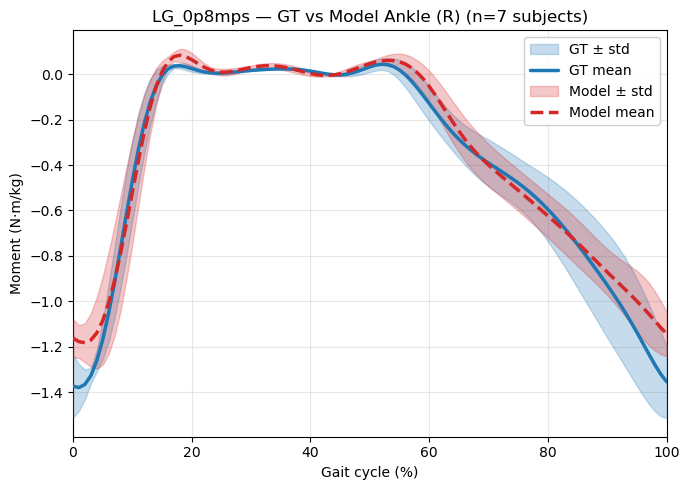

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_ankle_angle_r_LG_1p2mps.png


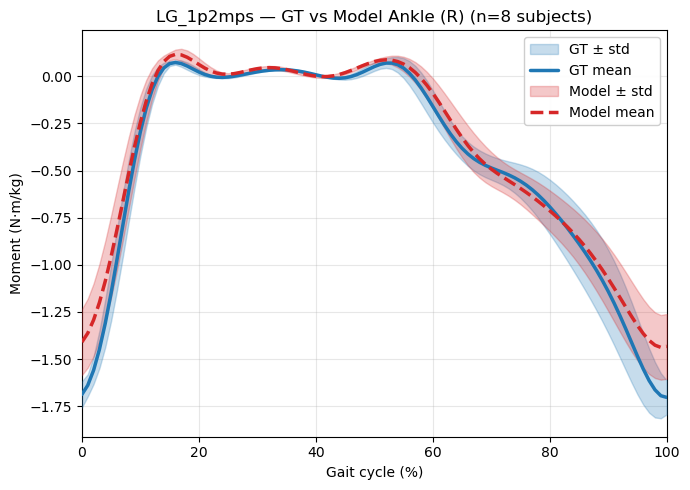

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_ankle_angle_r_LG_1p6mps.png


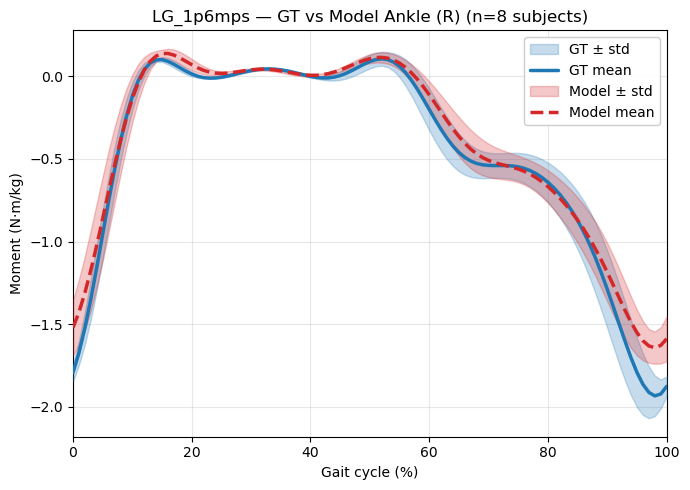

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_ankle_angle_r_RA_0p8mps.png


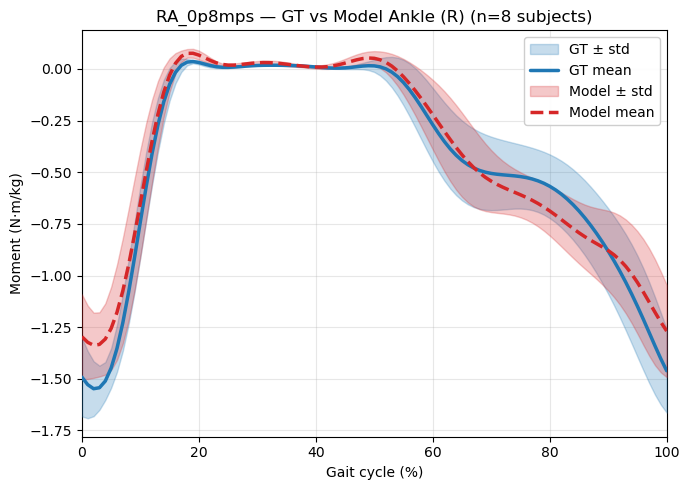

Saved /home/metamobility3/Jinwoo/os_kinetics/analysis/figures/awinda_gait_cycles/awinda_comparison_ankle_angle_r_RD_0p8mps.png


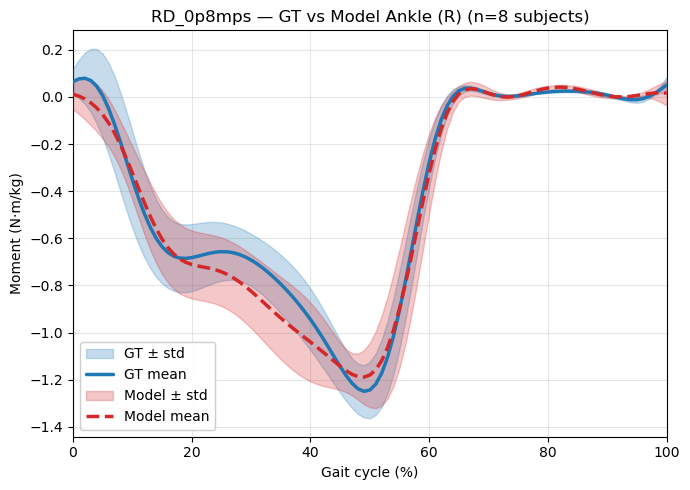

In [18]:
def plot_condition_joint_comparison(
    condition: str,
    joint_idx: int,
    joint_name: str,
    trials: List[Dict],
    ax=None,
    save_path: Optional[Path] = None,
):
    if not trials:
        raise ValueError(f'No trials for condition {condition}')

    pct = trials[0]['pct']
    
    gt_subject_means = [np.asarray(t['gt_subject_means'][joint_idx], dtype=np.float64) for t in trials]
    gt_grand_mean = np.mean(gt_subject_means, axis=0)
    gt_grand_std = np.std(gt_subject_means, axis=0, ddof=1) if len(gt_subject_means) > 1 else np.zeros_like(gt_grand_mean)
    
    model_subject_means = [np.asarray(t['model_subject_means'][joint_idx], dtype=np.float64) for t in trials]
    model_grand_mean = np.mean(model_subject_means, axis=0)
    model_grand_std = np.std(model_subject_means, axis=0, ddof=1) if len(model_subject_means) > 1 else np.zeros_like(model_grand_mean)

    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(7, 5))
    else:
        fig = ax.figure

    gt_color = '#1f77b4'
    ax.fill_between(
        pct,
        gt_grand_mean - gt_grand_std,
        gt_grand_mean + gt_grand_std,
        color=gt_color,
        alpha=0.25,
        label='GT ± std',
        zorder=5,
    )
    ax.plot(
        pct,
        gt_grand_mean,
        color=gt_color,
        lw=2.5,
        solid_capstyle='round',
        label='GT mean',
        zorder=10,
    )
    
    model_color = '#d62728'
    ax.fill_between(
        pct,
        model_grand_mean - model_grand_std,
        model_grand_mean + model_grand_std,
        color=model_color,
        alpha=0.25,
        label='Model ± std',
        zorder=6,
    )
    ax.plot(
        pct,
        model_grand_mean,
        color=model_color,
        lw=2.5,
        solid_capstyle='round',
        label='Model mean',
        zorder=11,
        linestyle='--',
    )
    
    ax.axvline(0.0, color='0.75', lw=0.8, zorder=0)
    ax.set_xlim(0, 100)
    ax.set_xlabel('Gait cycle (%)')
    ax.set_ylabel('Moment (N·m/kg)')
    ax.set_title(f'{condition} — GT vs Model {joint_name} (n={len(trials)} subjects)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', frameon=True, framealpha=0.95, fontsize=10)

    if created_fig:
        fig.tight_layout()
        if save_path is not None:
            save_path.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f'Saved {save_path}')
        plt.show()

    return fig, ax


# Plot each joint separately
for j_idx, (joint_name, joint_label) in enumerate(zip(RIGHT_CHANNELS, RIGHT_LABELS)):
    print(f'\n=== Plotting GT vs Model for {joint_name} ===')
    for condition in conditions:
        plot_condition_joint_comparison(
            condition,
            j_idx,
            joint_label,
            GAIT_BY_CONDITION[condition],
            save_path=FIG_DIR / f'awinda_comparison_{joint_name}_{condition}.png',
        )